In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

## Classificação de fácies litológicas

Na aula anterior, foi realizado o pré-processamento do conjunto de dados facies_vector.csv, disponibilizado no desafio de aprendizado de máquina proposto pela SEG. A seguir, apresenta-se a descrição do dataset utilizada na última aula.

## Descrição do conjunto de dados

Neste notebook, utilizaremos um conjunto de dados disponibilizado no desafio de *machine learning* promovido pela **SEG (Society of Exploration Geophysicists)** em 2016. O desafio pode ser encontrado no repositório oficial: <a href="https://github.com/seg/2016-ml-contest">SEG 2016 Machine Learning Contest</a>.

O objetivo do problema é realizar a **classificação de fácies litológicas** a partir de dados de perfis de poço. Em outras palavras, queremos treinar modelos de aprendizado de máquina capazes de reconhecer diferentes tipos de rochas ou associações litológicas com base em atributos medidos ao longo do poço.

A variável alvo do problema é a coluna **`Facies`**, que representa a classe litológica de cada amostra. Neste conjunto de dados, as fácies foram divididas em **9 classes**:

1. **Nonmarine sandstone**
2. **Nonmarine coarse siltstone**
3. **Nonmarine fine siltstone**
4. **Marine siltstone and shale**
5. **Mudstone (limestone)**
6. **Wackestone (limestone)**
7. **Dolomite**
8. **Packstone-grainstone (limestone)**
9. **Phylloid-algal bafflestone (limestone)**

Essas classes também possuem siglas, que facilitam a interpretação e a visualização dos resultados:

| Label | Sigla | Fácies adjacentes | Descrição |
|:----:|:-----:|:-----------------:|-----------|
| 1 | SS   | 2 | Nonmarine sandstone |
| 2 | CSiS | 1, 3 | Nonmarine coarse siltstone |
| 3 | FSiS | 2 | Nonmarine fine siltstone |
| 4 | SiSh | 5 | Marine siltstone and shale |
| 5 | MS   | 4, 6 | Mudstone (limestone) |
| 6 | WS   | 5, 7 | Wackestone (limestone) |
| 7 | D    | 6, 8 | Dolomite |
| 8 | PS   | 6, 7, 9 | Packstone-grainstone (limestone) |
| 9 | BS   | 7, 8 | Phylloid-algal bafflestone (limestone) |

### O que significa "fácies adjacentes"?

A coluna **fácies adjacentes** indica classes que são geologicamente próximas ou que podem ser mais facilmente confundidas entre si. Isso é importante porque, em muitos problemas reais de geologia e geofísica, a transição entre litologias não ocorre de forma abrupta. Em vez disso, pode haver mudanças graduais nas propriedades das rochas, tornando a classificação mais desafiadora.

Ao longo desta aula, utilizaremos esse dataset para explorar técnicas de aprendizado de máquina voltadas à **classificação de fácies**, discutindo tanto os aspectos computacionais quanto a interpretação geofísica dos resultados.

In [ ]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Observação: funções de plotagem geradas com ajuda de IA generativa (ChatGPT) e adaptadas para o contexto do curso.

def plot_well_logs(
    df,
    well_name,
    cols,
    depth_col='Depth',
    well_col='Well Name',
    depth_unit='m',
    x_units=None,
    figsize=(12, 12),
    title=None,
    sharey=True,
    facies_col=None,
    facies_colors=None,
    show_facies_legend=True
):
    df_well = df[df[well_col] == well_name].copy()

    n_logs = len(cols)
    ncols_total = n_logs + (1 if facies_col is not None else 0)

    width_ratios = [1] * n_logs
    if facies_col is not None:
        width_ratios.append(0.4)

    fig, axes = plt.subplots(
        ncols=ncols_total,
        figsize=figsize,
        sharey=sharey,
        gridspec_kw={'width_ratios': width_ratios}
    )

    if ncols_total == 1:
        axes = [axes]
    else:
        axes = np.atleast_1d(axes)

    if x_units is None:
        x_units = {}

    for col, ax in zip(cols, axes[:n_logs]):
        ax.plot(df_well[col], df_well[depth_col])
        ax.invert_yaxis()
        ax.grid(True)
        ax.set_title(col)
        ax.set_xlabel(x_units.get(col, ''))

    axes[0].set_ylabel(f'{depth_col} ({depth_unit})')

    if facies_col is not None:
        facies_ax = axes[-1]
        facies_values = df_well[facies_col]

        # Converte para categorias
        facies_cat = facies_values.astype('category')
        facies_codes = facies_cat.cat.codes.to_numpy()
        facies_labels = list(facies_cat.cat.categories)

        facies_image = np.repeat(facies_codes.reshape(-1, 1), 20, axis=1)

        if facies_colors is None:
            facies_colors = [
                '#F4D03F', '#DC7633', '#A569BD', '#5DADE2', '#45B39D',
                '#58D68D', '#AF7AC5', '#F5B041', '#EC7063'
            ]

        cmap = ListedColormap(facies_colors[:len(facies_labels)])

        facies_ax.imshow(
            facies_image,
            aspect='auto',
            interpolation='none',
            cmap=cmap,
            extent=[0, 1, df_well[depth_col].max(), df_well[depth_col].min()]
        )

        facies_ax.set_title(facies_col)
        facies_ax.set_xticks([])

        # legenda
        if show_facies_legend:
            legend_elements = [
                Patch(facecolor=facies_colors[i], edgecolor='black', label=facies_labels[i])
                for i in range(len(facies_labels))
            ]

            fig.legend(
                handles=legend_elements,
                loc='center left',
                bbox_to_anchor=(1.02, 0.5),
                title='Fácies'
            )

    if title is None:
        title = f'Poço: {well_name}'

    fig.suptitle(title, fontsize=16, y=1.02)
    fig.tight_layout()

    return fig, axes



def plot_well_logs_with_facies_comparison(
    df,
    well_name,
    cols,
    true_facies_col,
    pred_facies_col,
    depth_col='Depth',
    well_col='Well Name',
    depth_unit='m',
    x_units=None,
    figsize=(14, 12),
    title=None,
    sharey=True,
    facies_colors=None,
    facies_order=None,
    show_facies_legend=True
):
    """
    Plota curvas de perfis de um poço e compara as fácies esperadas e preditas.

    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame contendo os dados dos perfis.
    well_name : str
        Nome do poço a ser plotado.
    cols : list of str
        Lista com os nomes das colunas de perfis a serem exibidas.
    true_facies_col : str
        Nome da coluna com as fácies esperadas.
    pred_facies_col : str
        Nome da coluna com as fácies preditas.
    depth_col : str, default='Depth'
        Nome da coluna de profundidade.
    well_col : str, default='Well Name'
        Nome da coluna que identifica o poço.
    depth_unit : str, default='m'
        Unidade da profundidade.
    x_units : dict or None, default=None
        Dicionário com as unidades das curvas.
    figsize : tuple, default=(14, 12)
        Tamanho da figura.
    title : str or None, default=None
        Título geral da figura.
    sharey : bool, default=True
        Se True, compartilha o eixo y entre os subplots.
    facies_colors : list or None, default=None
        Lista de cores para as fácies.
    facies_order : list or None, default=None
        Ordem desejada das fácies.
    show_facies_legend : bool, default=True
        Se True, exibe a legenda das fácies.

    Retorna
    -------
    fig, axes
        Objetos da figura e dos eixos.
    """
    df_well = df[df[well_col] == well_name].copy()

    n_logs = len(cols)
    ncols_total = n_logs + 2  # esperado + predito
    width_ratios = [1] * n_logs + [0.35, 0.35]

    fig, axes = plt.subplots(
        ncols=ncols_total,
        figsize=figsize,
        sharey=sharey,
        gridspec_kw={'width_ratios': width_ratios}
    )

    axes = np.atleast_1d(axes)

    if x_units is None:
        x_units = {}

    # Perfis
    for col, ax in zip(cols, axes[:n_logs]):
        ax.plot(df_well[col], df_well[depth_col])
        ax.invert_yaxis()
        ax.grid(True)
        ax.set_title(col)
        ax.set_xlabel(x_units.get(col, ''))

    axes[0].set_ylabel(f'{depth_col} ({depth_unit})')

    # Construção de categorias consistentes entre esperado e predito
    all_facies = pd.concat([
        df_well[true_facies_col],
        df_well[pred_facies_col]
    ], axis=0).dropna()

    if facies_order is None:
        facies_labels = list(pd.Series(all_facies).astype('category').cat.categories)
    else:
        facies_labels = facies_order

    true_cat = pd.Categorical(df_well[true_facies_col], categories=facies_labels, ordered=True)
    pred_cat = pd.Categorical(df_well[pred_facies_col], categories=facies_labels, ordered=True)

    true_codes = pd.Series(true_cat).cat.codes.to_numpy()
    pred_codes = pd.Series(pred_cat).cat.codes.to_numpy()

    true_img = np.repeat(true_codes.reshape(-1, 1), 20, axis=1)
    pred_img = np.repeat(pred_codes.reshape(-1, 1), 20, axis=1)

    if facies_colors is None:
        facies_colors = [
            '#F4D03F', '#DC7633', '#A569BD', '#5DADE2', '#45B39D',
            '#58D68D', '#AF7AC5', '#F5B041', '#EC7063'
        ]

    cmap = ListedColormap(facies_colors[:len(facies_labels)])

    # Esperado
    ax_true = axes[-2]
    ax_true.imshow(
        true_img,
        aspect='auto',
        interpolation='none',
        cmap=cmap,
        extent=[0, 1, df_well[depth_col].max(), df_well[depth_col].min()]
    )
    ax_true.set_title('Esperado')
    ax_true.set_xticks([])

    # Predito
    ax_pred = axes[-1]
    ax_pred.imshow(
        pred_img,
        aspect='auto',
        interpolation='none',
        cmap=cmap,
        extent=[0, 1, df_well[depth_col].max(), df_well[depth_col].min()]
    )
    ax_pred.set_title('Predito')
    ax_pred.set_xticks([])

    # Legenda
    if show_facies_legend:
        legend_elements = [
            Patch(facecolor=facies_colors[i], edgecolor='black', label=facies_labels[i])
            for i in range(len(facies_labels))
        ]

        fig.legend(
            handles=legend_elements,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            title='Fácies'
        )

    if title is None:
        title = f'Poço: {well_name}'

    fig.suptitle(title, fontsize=16, y=1.02)
    fig.tight_layout()

    return fig, axes

In [120]:
df = pd.read_csv('..\\..\\data\\csv\\facies_vectors_pre_proc.csv')
df.head()

,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS,Labels_char,PHID,PHIN,Formation_num,PE_reg_lin,KNN_PE,PE_Rec
0,3,A1 SH,SHRIMPLIN,2793.0,77.45,0.664,9.9,11.915,4.6,2,1.000,Nonmarine fine siltstone,6.965,16.865,1,3.385422,3.4,4.6
1,3,A1 SH,SHRIMPLIN,2793.5,78.26,0.661,14.2,12.565,4.1,2,0.979,Nonmarine fine siltstone,5.465,19.665,1,3.405093,4.1,4.1
2,3,A1 SH,SHRIMPLIN,2794.0,79.05,0.658,14.8,13.050,3.6,2,0.957,Nonmarine fine siltstone,5.650,20.450,1,3.393572,3.6,3.6
3,3,A1 SH,SHRIMPLIN,2794.5,86.10,0.655,13.9,13.115,3.5,2,0.936,Nonmarine fine siltstone,6.165,20.065,1,3.381227,3.5,3.5
4,3,A1 SH,SHRIMPLIN,2795.0,74.58,0.647,13.5,13.300,3.4,2,0.915,Nonmarine fine siltstone,6.550,20.050,1,3.378932,3.4,3.4


In [121]:
# Separando os atributos e a variável alvo

cols_num = df.select_dtypes(include=[np.number]).columns.tolist()[1:-3] # Excluindo as colunas de PE_reg_lin e KNN_PE
cols_num.remove('PE') # Excluindo a coluna de PE, pois é a variável alvo

cols_num = cols_num+['PE_Rec']
cols_num

['Depth',
 'GR',
 'ILD_log10',
 'DeltaPHI',
 'PHIND',
 'NM_M',
 'RELPOS',
 'PHID',
 'PHIN',
 'Formation_num',
 'PE_Rec']

(<Figure size 1200x1200 with 6 Axes>,
 array([<Axes: title={'center': 'GR'}, xlabel='API', ylabel='Depth (m)'>,
        <Axes: title={'center': 'ILD_log10'}, xlabel='log10(ohm.m)'>,
        <Axes: title={'center': 'DeltaPHI'}, xlabel='v/v'>,
        <Axes: title={'center': 'PHIND'}, xlabel='v/v'>,
        <Axes: title={'center': 'PE_Rec'}>,
        <Axes: title={'center': 'Labels_char'}>], dtype=object))

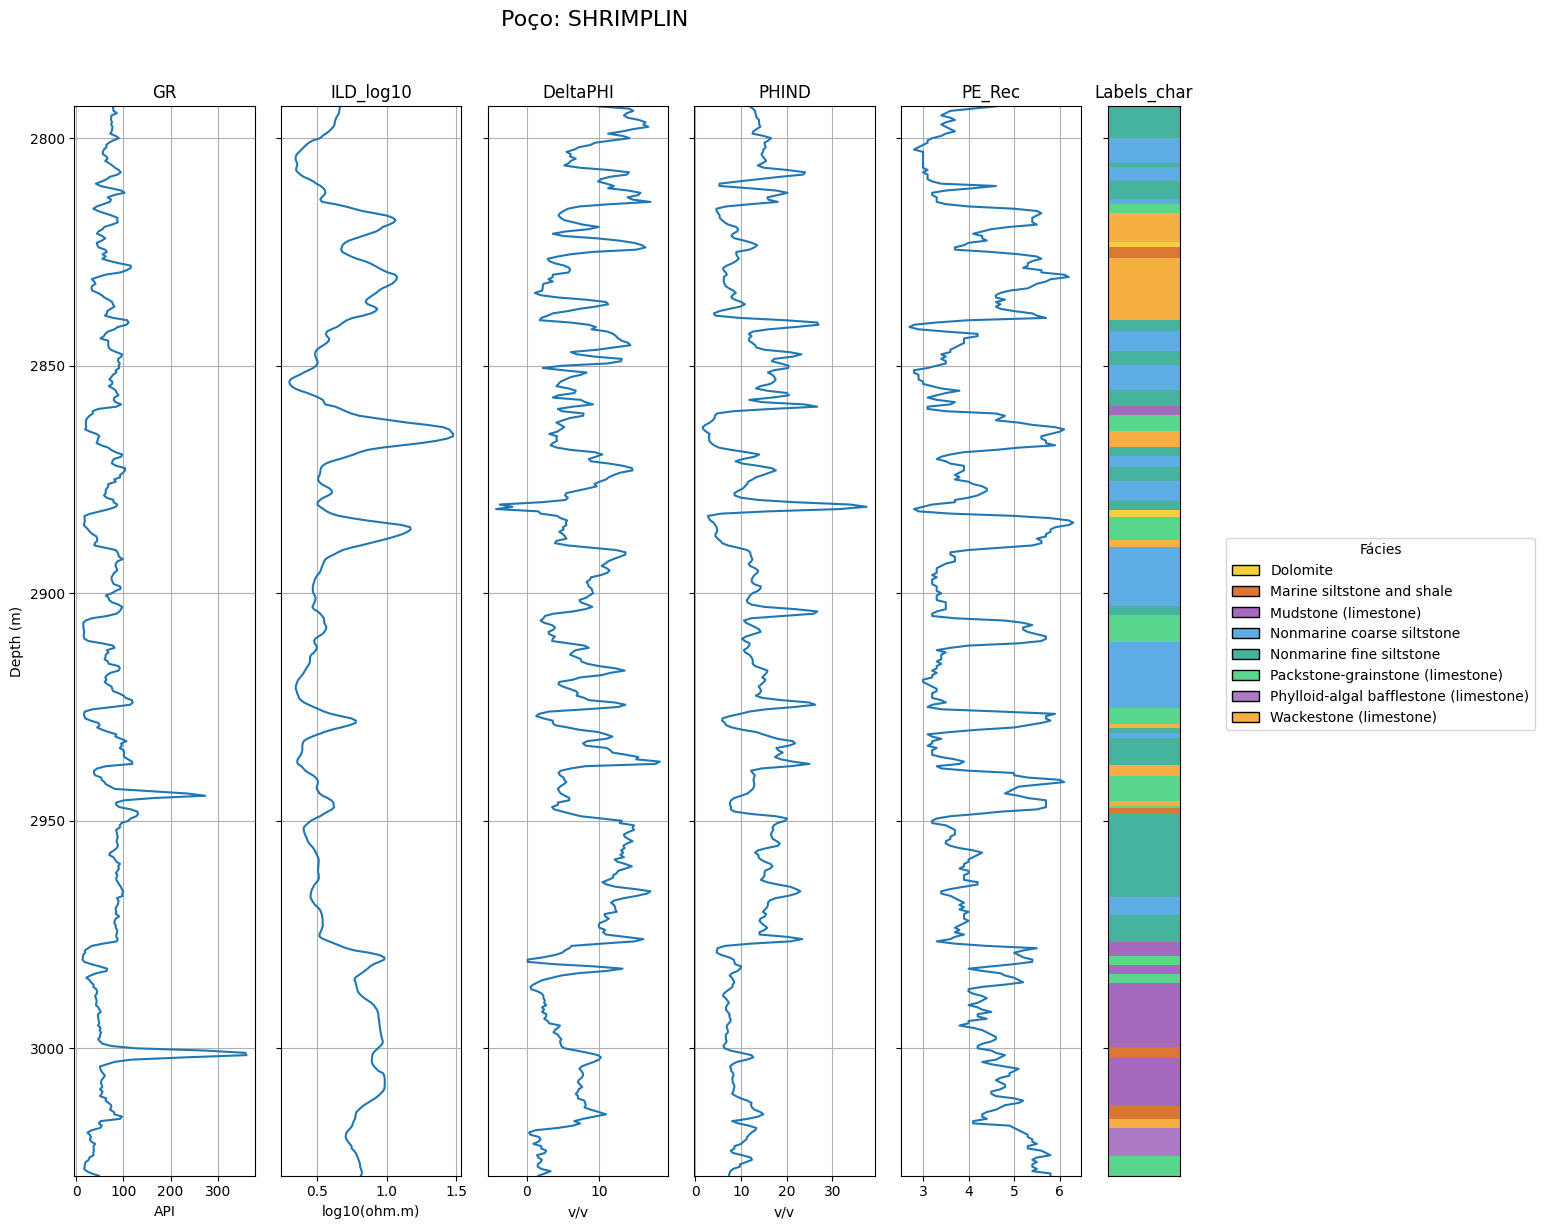

In [122]:
cols = ['GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'PE_Rec','Labels_char']

unit = {
        'GR': 'API',
        'ILD_log10': 'log10(ohm.m)',
        'DeltaPHI': 'v/v',
        'PHIND': 'v/v',
        'PE': 'b/e'
    }

plot_well_logs(
    df=df,
    well_name='SHRIMPLIN',
    cols=cols[:-1],
    x_units=unit,
    facies_col='Labels_char',
    show_facies_legend=True
)

In [123]:
mapping = df[['Facies', 'Labels_char']].drop_duplicates().set_index('Facies')['Labels_char'].to_dict()
mapping

{3: 'Nonmarine fine siltstone',
 2: 'Nonmarine coarse siltstone',
 8: 'Packstone-grainstone (limestone)',
 6: 'Wackestone (limestone)',
 7: 'Dolomite',
 4: 'Marine siltstone and shale',
 5: 'Mudstone (limestone)',
 9: 'Phylloid-algal bafflestone (limestone)',
 1: 'Nonmarine sandstone'}

In [124]:
labels = sorted(mapping.keys())
target_names = [mapping[label] for label in labels]
target_names

['Nonmarine sandstone',
 'Nonmarine coarse siltstone',
 'Nonmarine fine siltstone',
 'Marine siltstone and shale',
 'Mudstone (limestone)',
 'Wackestone (limestone)',
 'Dolomite',
 'Packstone-grainstone (limestone)',
 'Phylloid-algal bafflestone (limestone)']

In [125]:
X = df[cols_num]
X_sem_PE_Rec = df[cols_num[:-1]] # Excluindo a coluna de PE_Rec para comparação
y = df['Facies']

In [126]:
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [127]:
# Realizando a classificação com a regressão logística
log_reg = LogisticRegression()

log_reg.fit(X_train, y_train)

y_pred_log_reg = log_reg.predict(X_test)

In [128]:
print("Relatório de Classificação (Treino) - Regressão Logística:")
print(classification_report(y_train, log_reg.predict(X_train),target_names=target_names))
print("Matriz de Confusão (Treino) - Regressão Logística:")
print(confusion_matrix(y_train, log_reg.predict(X_train), labels=labels))

Relatório de Classificação (Treino) - Regressão Logística:
                                        precision    recall  f1-score   support

                   Nonmarine sandstone       0.72      0.61      0.66       214
            Nonmarine coarse siltstone       0.52      0.70      0.60       735
              Nonmarine fine siltstone       0.62      0.59      0.60       628
            Marine siltstone and shale       0.46      0.32      0.37       219
                  Mudstone (limestone)       0.33      0.21      0.26       242
                Wackestone (limestone)       0.47      0.49      0.48       470
                              Dolomite       0.39      0.15      0.22       112
      Packstone-grainstone (limestone)       0.54      0.59      0.57       555
Phylloid-algal bafflestone (limestone)       0.63      0.41      0.50       144

                              accuracy                           0.53      3319
                             macro avg       0.52      0.45

In [129]:
print("Relatório de Classificação (Teste) - Regressão Logística:")
print(classification_report(y_test, y_pred_log_reg,target_names=target_names))
print("Matriz de Confusão (Teste) - Regressão Logística:")
print(confusion_matrix(y_test, y_pred_log_reg, labels=labels))

Relatório de Classificação (Teste) - Regressão Logística:
                                        precision    recall  f1-score   support

                   Nonmarine sandstone       0.68      0.56      0.61        54
            Nonmarine coarse siltstone       0.51      0.64      0.57       205
              Nonmarine fine siltstone       0.55      0.55      0.55       152
            Marine siltstone and shale       0.39      0.23      0.29        52
                  Mudstone (limestone)       0.12      0.11      0.12        54
                Wackestone (limestone)       0.39      0.39      0.39       112
                              Dolomite       1.00      0.28      0.43        29
      Packstone-grainstone (limestone)       0.50      0.60      0.54       131
Phylloid-algal bafflestone (limestone)       0.78      0.44      0.56        41

                              accuracy                           0.50       830
                             macro avg       0.55      0.42 

In [130]:
#Treinando sem o PE_Rec para comparação

log_reg = LogisticRegression()

log_reg.fit(X_train[:,:-1], y_train)

y_pred_log_reg = log_reg.predict(X_test[:,:-1])

In [131]:
print("Relatório de Classificação (Treino) - Regressão Logística:")
print(classification_report(y_train, log_reg.predict(X_train[:,:-1]), target_names=target_names))
print("Matriz de Confusão (Treino) - Regressão Logística:")
print(confusion_matrix(y_train, log_reg.predict(X_train[:,:-1]), labels=labels))

Relatório de Classificação (Treino) - Regressão Logística:
                                        precision    recall  f1-score   support

                   Nonmarine sandstone       0.67      0.47      0.55       214
            Nonmarine coarse siltstone       0.48      0.65      0.55       735
              Nonmarine fine siltstone       0.61      0.60      0.60       628
            Marine siltstone and shale       0.40      0.23      0.29       219
                  Mudstone (limestone)       0.40      0.23      0.29       242
                Wackestone (limestone)       0.45      0.47      0.46       470
                              Dolomite       0.15      0.04      0.07       112
      Packstone-grainstone (limestone)       0.43      0.51      0.47       555
Phylloid-algal bafflestone (limestone)       0.64      0.47      0.54       144

                              accuracy                           0.49      3319
                             macro avg       0.47      0.41

In [132]:
print("Relatório de Classificação (Teste) - Regressão Logística:")
print(classification_report(y_test, y_pred_log_reg, target_names=target_names))
print("Matriz de Confusão (Teste) - Regressão Logística:")
print(confusion_matrix(y_test, y_pred_log_reg, labels=labels))

Relatório de Classificação (Teste) - Regressão Logística:
                                        precision    recall  f1-score   support

                   Nonmarine sandstone       0.58      0.39      0.47        54
            Nonmarine coarse siltstone       0.45      0.56      0.50       205
              Nonmarine fine siltstone       0.58      0.59      0.59       152
            Marine siltstone and shale       0.40      0.15      0.22        52
                  Mudstone (limestone)       0.19      0.17      0.18        54
                Wackestone (limestone)       0.34      0.40      0.37       112
                              Dolomite       0.44      0.14      0.21        29
      Packstone-grainstone (limestone)       0.35      0.40      0.37       131
Phylloid-algal bafflestone (limestone)       0.70      0.46      0.56        41

                              accuracy                           0.44       830
                             macro avg       0.45      0.36 

In [133]:
# Otimizando a regressão logística com GridSearchCV

lr = LogisticRegression()

param_grid = {
    'C': [0.001, 0.01, 0.1, 1,5,10],
}

lr_cv = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, n_jobs=-1)
lr_cv.fit(X_train, y_train)

y_pred_log_reg = lr_cv.predict(X_test)

print("Melhores hiperparâmetros encontrados:", lr_cv.best_params_)

Melhores hiperparâmetros encontrados: {'C': 10}


In [134]:
print("Relatório de Classificação (Treino) - Regressão Logística:")
print(classification_report(y_train, lr_cv.predict(X_train), target_names=target_names))
print("Matriz de Confusão (Treino) - Regressão Logística:")
print(confusion_matrix(y_train, lr_cv.predict(X_train), labels=labels))

Relatório de Classificação (Treino) - Regressão Logística:
                                        precision    recall  f1-score   support

                   Nonmarine sandstone       0.71      0.63      0.67       214
            Nonmarine coarse siltstone       0.52      0.69      0.59       735
              Nonmarine fine siltstone       0.62      0.59      0.60       628
            Marine siltstone and shale       0.46      0.32      0.38       219
                  Mudstone (limestone)       0.33      0.21      0.26       242
                Wackestone (limestone)       0.46      0.49      0.48       470
                              Dolomite       0.40      0.17      0.24       112
      Packstone-grainstone (limestone)       0.54      0.59      0.56       555
Phylloid-algal bafflestone (limestone)       0.63      0.41      0.50       144

                              accuracy                           0.53      3319
                             macro avg       0.52      0.46

In [135]:
print("Relatório de Classificação (Teste) - Regressão Logística:")
print(classification_report(y_test, y_pred_log_reg, target_names=target_names))
print("Matriz de Confusão (Teste) - Regressão Logística:")
print(confusion_matrix(y_test, y_pred_log_reg, labels=labels))

Relatório de Classificação (Teste) - Regressão Logística:
                                        precision    recall  f1-score   support

                   Nonmarine sandstone       0.68      0.59      0.63        54
            Nonmarine coarse siltstone       0.52      0.64      0.57       205
              Nonmarine fine siltstone       0.56      0.55      0.55       152
            Marine siltstone and shale       0.39      0.23      0.29        52
                  Mudstone (limestone)       0.12      0.11      0.12        54
                Wackestone (limestone)       0.38      0.38      0.38       112
                              Dolomite       1.00      0.28      0.43        29
      Packstone-grainstone (limestone)       0.50      0.59      0.54       131
Phylloid-algal bafflestone (limestone)       0.78      0.44      0.56        41

                              accuracy                           0.50       830
                             macro avg       0.55      0.42 

In [138]:
# Realizando a mesma classificação com o KNN para comparação

knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': np.arange(3, 51,2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'p': np.arange(1, 6)
}

knn_cv = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, n_jobs=-1)
knn_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': array([ 3, 5..., 45, 47, 49]), 'p': array([1, 2, 3, 4, 5]), 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each 

In [139]:
knn_cv.best_params_

{'metric': 'manhattan', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}

In [141]:
knn_pred = knn_cv.predict(X_test)

In [140]:
print("Relatório de Classificação (Treino) - Regressão Logística:")
print(classification_report(y_train, knn_cv.predict(X_train), target_names=target_names))
print("Matriz de Confusão (Treino) - Regressão Logística:")
print(confusion_matrix(y_train, knn_cv.predict(X_train), labels=labels))

Relatório de Classificação (Treino) - Regressão Logística:
                                        precision    recall  f1-score   support

                   Nonmarine sandstone       1.00      1.00      1.00       214
            Nonmarine coarse siltstone       1.00      1.00      1.00       735
              Nonmarine fine siltstone       1.00      1.00      1.00       628
            Marine siltstone and shale       1.00      1.00      1.00       219
                  Mudstone (limestone)       1.00      1.00      1.00       242
                Wackestone (limestone)       1.00      1.00      1.00       470
                              Dolomite       1.00      1.00      1.00       112
      Packstone-grainstone (limestone)       1.00      1.00      1.00       555
Phylloid-algal bafflestone (limestone)       1.00      1.00      1.00       144

                              accuracy                           1.00      3319
                             macro avg       1.00      1.00

In [142]:
print("Relatório de Classificação (Teste) - KNN:")
print(classification_report(y_test, knn_pred, target_names=target_names))
print("Matriz de Confusão (Teste) - KNN:")
print(confusion_matrix(y_test, knn_pred, labels=labels))

Relatório de Classificação (Teste) - KNN:
                                        precision    recall  f1-score   support

                   Nonmarine sandstone       0.81      0.87      0.84        54
            Nonmarine coarse siltstone       0.83      0.86      0.85       205
              Nonmarine fine siltstone       0.80      0.79      0.79       152
            Marine siltstone and shale       0.80      0.79      0.80        52
                  Mudstone (limestone)       0.64      0.67      0.65        54
                Wackestone (limestone)       0.76      0.71      0.73       112
                              Dolomite       0.83      0.69      0.75        29
      Packstone-grainstone (limestone)       0.81      0.77      0.79       131
Phylloid-algal bafflestone (limestone)       0.82      1.00      0.90        41

                              accuracy                           0.80       830
                             macro avg       0.79      0.79      0.79       

In [158]:
df['Labels_pred'] = knn_cv.predict(X_scaled)

In [159]:
df['Labels_pred'] = df['Labels_pred'].map(mapping)
# sorted by keys

mapping_sorted = {k: mapping[k] for k in sorted(mapping.keys())}
mapping_sorted

{1: 'Nonmarine sandstone',
 2: 'Nonmarine coarse siltstone',
 3: 'Nonmarine fine siltstone',
 4: 'Marine siltstone and shale',
 5: 'Mudstone (limestone)',
 6: 'Wackestone (limestone)',
 7: 'Dolomite',
 8: 'Packstone-grainstone (limestone)',
 9: 'Phylloid-algal bafflestone (limestone)'}

In [160]:
# Puxando as labels organizadas do mapping
labels_sorted = [mapping_sorted[label] for label in sorted(mapping_sorted.keys())]

labels_sorted

['Nonmarine sandstone',
 'Nonmarine coarse siltstone',
 'Nonmarine fine siltstone',
 'Marine siltstone and shale',
 'Mudstone (limestone)',
 'Wackestone (limestone)',
 'Dolomite',
 'Packstone-grainstone (limestone)',
 'Phylloid-algal bafflestone (limestone)']

In [ ]:
import ipywidgets as widgets
from ipywidgets import interact

wells = sorted(df['Well Name'].unique())

cols_plot = ['GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'PE','PE_reg_lin','KNN_PE']

x_units = {
    'GR': 'API',
    'ILD_log10': 'log10(ohm.m)',
    'DeltaPHI': 'v/v',
    'PHIND': 'v/v',
    'PE': 'b/e',
    'PE_reg_lin': 'b/e',
    'KNN_PE': 'b/e'
}

def interactive_plot(well_name):
    plt.close('all')
    plot_well_logs_with_facies_comparison(
        df=df,
        well_name=well_name,
        cols=['GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'PE_Rec'],
        true_facies_col='Labels_char',
        pred_facies_col='Labels_pred',
        x_units=x_units,
        facies_order=labels_sorted
    )
    plt.show()

interact(interactive_plot, well_name=wells)

interactive(children=(Dropdown(description='well_name', options=('ALEXANDER D', 'CHURCHMAN BIBLE', 'CROSS H CA…

<function __main__.interactive_plot(well_name)>